In [1]:
import pandas as pd
import numpy as np
import re
import pickle
from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from gensim.models import KeyedVectors, Word2Vec
from pathlib import Path
# from datetime import datetime
# from collections import Counter
import json
# from sklearn.model_selection import GridSearchCV
from deep_translator import GoogleTranslator
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
comparsion_dataset = pd.read_csv('./data/news.csv')

# Приведем датасет к необходимому виду

In [3]:
comparsion_dataset.drop(columns=['source', 'publication_date', 'rubric', 'subrubric', 'tags'], inplace=True)

In [4]:
try:
    russian_stopwords = stopwords.words('russian')
    english_stopwords = stopwords.words('english')
except:
    nltk.download('stopwords')
    russian_stopwords = stopwords.words('russian')
    english_stopwords = stopwords.words('english')

In [5]:
def combine_features(row):
    headline = row['headline_clean']
    body_words = row['body_clean'].split()
    body = ' '.join(body_words)
    return f"{headline} {body}"

def preprocess_text(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in russian_stopwords and len(word) > 2]
    
    return ' '.join(words)

def preprocess_text_en(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in english_stopwords and len(word) > 2]
    
    return ' '.join(words)

In [6]:
comparsion_dataset = comparsion_dataset.rename(columns={'title': 'Headline', 'text': 'articleBody'})
comparsion_dataset_eng = comparsion_dataset.copy()

comparsion_dataset['headline_clean'] = comparsion_dataset['Headline'].apply(preprocess_text)
comparsion_dataset['body_clean'] = comparsion_dataset['articleBody'].apply(preprocess_text)

comparsion_dataset['combined_text'] = comparsion_dataset.apply(combine_features, axis=1)

comparsion_dataset = comparsion_dataset[comparsion_dataset['combined_text'].str.len() > 10].reset_index(drop=True)



# comparsion_dataset_eng['headline_clean'] = comparsion_dataset_eng['Headline'].apply(preprocess_text_en)
# comparsion_dataset_eng['body_clean'] = comparsion_dataset_eng['articleBody'].apply(preprocess_text_en)

# comparsion_dataset_eng['combined_text'] = comparsion_dataset_eng.apply(combine_features, axis=1)

# comparsion_dataset_eng = comparsion_dataset_eng[comparsion_dataset_eng['combined_text'].str.len() > 10].reset_index(drop=True)


In [7]:
comparsion_dataset_eng

,Headline,articleBody
0,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...
1,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...
2,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...
3,«Предохраняться? А зачем?»,В 2019 году телеканал «Ю» запустил адаптацию з...
4,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...
...,...,...
21668,\n Россия прекратил...,\n\n \n \n \n \n \n...
21669,\n Во Владивостоке ...,\n\n \n \n \n \n \n...
21670,\n Дым от австралий...,\n\n \n \n \n \n \n...
21671,\n Около 200 жителе...,\n\n \n \n \n \n \n...


# Проведем сравнение разных моделей на английском и русском датасетах

---

### Как будем проводить сравнение:
- Возьмем датасет на русском языке и проверим, насколько точно модели на разных языках дадут ответы
- Для сравнения будем рассматривать 2 случая: **50** и **10** новостей

## Начнем с **логистической регрессии** на **TF-IDF**

In [8]:
mask = comparsion_dataset['combined_text'].astype(str).str.len() <= 500
# mask_eng = comparsion_dataset_eng['combined_text'].astype(str).str.len() <= 500

comparsion_dataset_50 = comparsion_dataset[mask].head(50).copy()
print(f"Работаем с первыми {len(comparsion_dataset_50)} строками датасета")
comparsion_dataset_10 = comparsion_dataset[mask].head(10).copy()
print(f"Работаем с первыми {len(comparsion_dataset_10)} строками датасета")
print('\n')
comparsion_dataset_50_eng = comparsion_dataset.copy()
print(f"Работаем с первыми {len(comparsion_dataset_50_eng)} строками датасета")
comparsion_dataset_10_eng = comparsion_dataset.copy()
print(f"Работаем с первыми {len(comparsion_dataset_10_eng)} строками датасета")

Работаем с первыми 50 строками датасета
Работаем с первыми 10 строками датасета


Работаем с первыми 21673 строками датасета
Работаем с первыми 21673 строками датасета


### Проверим датасет на русском языке

In [9]:
log_reg_rus = pickle.load(open('models/logistic_regression_model_tf.pkl', 'rb'))
ran_for_rus = pickle.load(open('models/random_forest_model_tf.pkl', 'rb'))
nai_bay_rus = pickle.load(open('models/naive_bayes_model_tf.pkl', 'rb'))
tfidf_vectorizer_rus = pickle.load(open('models/tfidf_vectorizer_tf.pkl', 'rb'))

In [10]:
X_test_50_rus = tfidf_vectorizer_rus.transform(comparsion_dataset_50['combined_text'])
y_pred_russian_50_tf_idf_logreg = log_reg_rus.predict(X_test_50_rus)

X_test_10_rus = tfidf_vectorizer_rus.transform(comparsion_dataset_10['combined_text'])
y_pred_russian_10_tf_idf_logreg = log_reg_rus.predict(X_test_10_rus)

In [11]:
total_rows = len(y_pred_russian_50_tf_idf_logreg)
predictions = np.sum(y_pred_russian_50_tf_idf_logreg == 1)
percentage_50_rus = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_50_rus:.2f}%)", 2*'\n')

total_rows = len(y_pred_russian_10_tf_idf_logreg)
predictions = np.sum(y_pred_russian_10_tf_idf_logreg == 1)
percentage_10_rus = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_10_rus:.2f}%)")

Общее количество строк в датасете: 50

Предсказания со значением 1: 48 (96.00%) 


Общее количество строк в датасете: 10

Предсказания со значением 1: 10 (100.00%)


### Проверим датасет на английском языке

In [48]:
log_reg_eng = pickle.load(open('models/logistic_regression_model_tf_eng.pkl', 'rb'))
ran_for_eng = pickle.load(open('models/random_forest_model_tf_eng.pkl', 'rb'))
nai_bay_eng = pickle.load(open('models/naive_bayes_model_tf_eng.pkl', 'rb'))
tfidf_vectorizer_eng = pickle.load(open('models/tfidf_vectorizer_tf_eng.pkl', 'rb'))

#### Переведем датасеты на английский язык

In [49]:
from deep_translator import GoogleTranslator
import time

translator = GoogleTranslator(source='auto', target='en')

def translate_to_en(text, max_retries=5, delay=2):
    for attempt in range(1, max_retries + 1):
        try:
            return translator.translate(text)
        except Exception as e:
            print(f"Ошибка перевода (попытка {attempt}/{max_retries}): {e}")
            if attempt == max_retries:
                return None
            time.sleep(delay)

mask_50 = (comparsion_dataset_50_eng['Headline'].astype(str) + ' ' +
           comparsion_dataset_50_eng['articleBody'].astype(str)
          ).apply(lambda x: len(x.split()) < 500)

mask_10 = (comparsion_dataset_10_eng['Headline'].astype(str) + ' ' +
           comparsion_dataset_10_eng['articleBody'].astype(str)
          ).apply(lambda x: len(x.split()) < 500)

comparsion_dataset_50_eng = comparsion_dataset_50_eng[mask_50].head(50).copy()
comparsion_dataset_10_eng = comparsion_dataset_10_eng[mask_10].head(10).copy()

translated_texts_50_eng = []
translated_texts_10_eng = []

translated_titles_50_eng = []
translated_bodies_50_eng = []

translated_titles_10_eng = []
translated_bodies_10_eng = []

for idx, row in comparsion_dataset_50_eng.iterrows():
    title_en = translate_to_en(row['Headline'])
    body_en = translate_to_en(row['articleBody'])

    translated_titles_50_eng.append(title_en)
    translated_bodies_50_eng.append(body_en)

    translated_texts_50_eng.append(f"{title_en} {body_en}")

comparsion_dataset_50_eng['Headline_en'] = translated_titles_50_eng
comparsion_dataset_50_eng['articleBody_en'] = translated_bodies_50_eng
comparsion_dataset_50_eng['combined_text_en'] = translated_texts_50_eng

for idx, row in comparsion_dataset_10_eng.iterrows():
    title_en = translate_to_en(row['Headline'])
    body_en = translate_to_en(row['articleBody'])

    translated_titles_10_eng.append(title_en)
    translated_bodies_10_eng.append(body_en)

    translated_texts_10_eng.append(f"{title_en} {body_en}")

comparsion_dataset_10_eng['Headline_en'] = translated_titles_10_eng
comparsion_dataset_10_eng['articleBody_en'] = translated_bodies_10_eng
comparsion_dataset_10_eng['combined_text_en'] = translated_texts_10_eng


In [50]:
X_test_50_eng = tfidf_vectorizer_eng.transform(comparsion_dataset_50_eng['combined_text_en'])
y_pred_english_50_tf_idf_logreg = log_reg_eng.predict(X_test_50_eng)

X_test_10_eng = tfidf_vectorizer_eng.transform(comparsion_dataset_10_eng['combined_text_en'])
y_pred_english_10_tf_idf_logreg = log_reg_eng.predict(X_test_10_eng)

## Проверим Random Forest + TF-IDF

In [51]:
y_pred_english_50_tf_idf_ran_for = ran_for_eng.predict(X_test_50_eng)
y_pred_russian_50_tf_idf_ran_for = ran_for_rus.predict(X_test_50_rus)

y_pred_english_10_tf_idf_ran_for = ran_for_eng.predict(X_test_10_eng)
y_pred_russian_10_tf_idf_ran_for = ran_for_rus.predict(X_test_10_rus)

## Проверим Naive Bayes + TF-IDF

In [52]:
y_pred_english_50_tf_idf_nai_bay = nai_bay_eng.predict(X_test_50_eng)
y_pred_russian_50_tf_idf_nai_bay = nai_bay_rus.predict(X_test_50_rus)

y_pred_english_10_tf_idf_nai_bay = nai_bay_eng.predict(X_test_10_eng)
y_pred_russian_10_tf_idf_nai_bay = nai_bay_rus.predict(X_test_10_rus)

---

In [53]:
models = {
    'Russian Naive Bayes 50': y_pred_russian_50_tf_idf_nai_bay, 
    'Russian Naive Bayes 10': y_pred_russian_10_tf_idf_nai_bay,
    'English Naive Bayes 50': y_pred_english_50_tf_idf_nai_bay,
    'English Naive Bayes 10': y_pred_english_10_tf_idf_nai_bay,
    'Russian Random Forest 50': y_pred_russian_50_tf_idf_ran_for,
    'Russian Random Forest 10': y_pred_russian_10_tf_idf_ran_for, 
    'English Random Forest 50': y_pred_english_50_tf_idf_ran_for,
    'English Random Forest 10': y_pred_english_10_tf_idf_ran_for,
    'Russian Logistic Regression 50': y_pred_russian_50_tf_idf_logreg,
    'Russian Logistic Regression 10': y_pred_russian_10_tf_idf_logreg,
    'English Logistic Regression 50': y_pred_english_50_tf_idf_logreg,
    'English Logistic Regression 10': y_pred_english_10_tf_idf_logreg
}

statistics_of_answers = {}

for name, model in models.items():
    total_rows = len(model)
    predictions = np.sum(model == 1)

    statistics_of_answers[name] = int(predictions)
    print(f"Получили количество предсказаний со значением 1 для {name} - {predictions}")

Получили количество предсказаний со значением 1 для Russian Naive Bayes 50 - 50
Получили количество предсказаний со значением 1 для Russian Naive Bayes 10 - 10
Получили количество предсказаний со значением 1 для English Naive Bayes 50 - 29
Получили количество предсказаний со значением 1 для English Naive Bayes 10 - 5
Получили количество предсказаний со значением 1 для Russian Random Forest 50 - 47
Получили количество предсказаний со значением 1 для Russian Random Forest 10 - 10
Получили количество предсказаний со значением 1 для English Random Forest 50 - 8
Получили количество предсказаний со значением 1 для English Random Forest 10 - 3
Получили количество предсказаний со значением 1 для Russian Logistic Regression 50 - 48
Получили количество предсказаний со значением 1 для Russian Logistic Regression 10 - 10
Получили количество предсказаний со значением 1 для English Logistic Regression 50 - 16
Получили количество предсказаний со значением 1 для English Logistic Regression 10 - 3


## Результаты и сравнение

In [54]:
model_pairs = [
    'Naive Bayes',
    'Random Forest',
    'Logistic Regression'
]

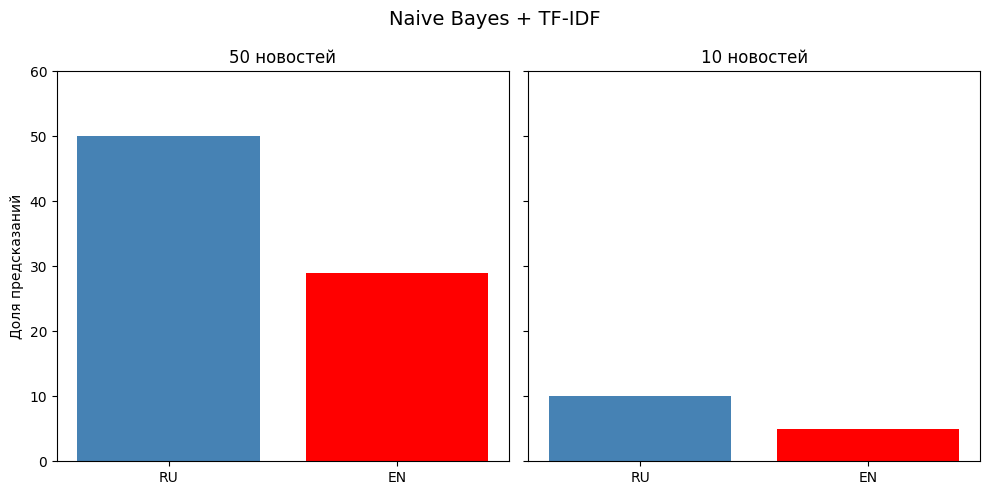

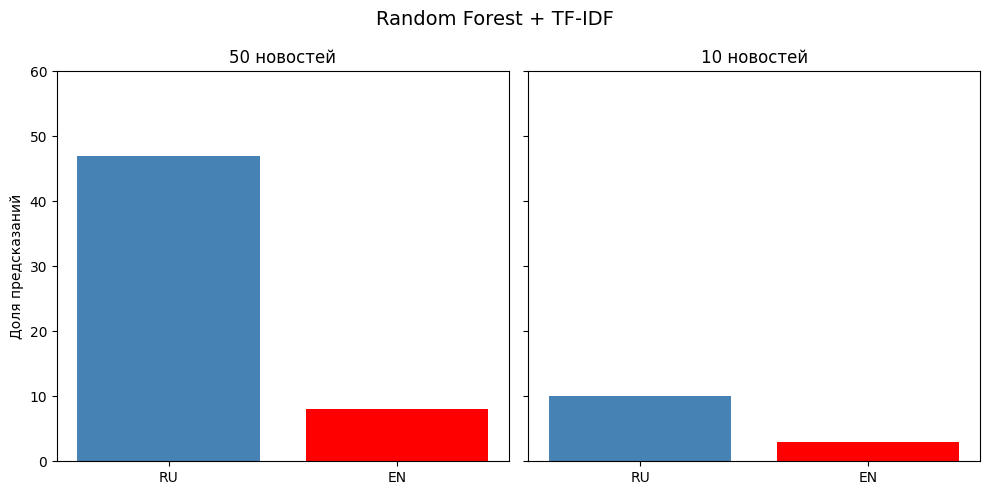

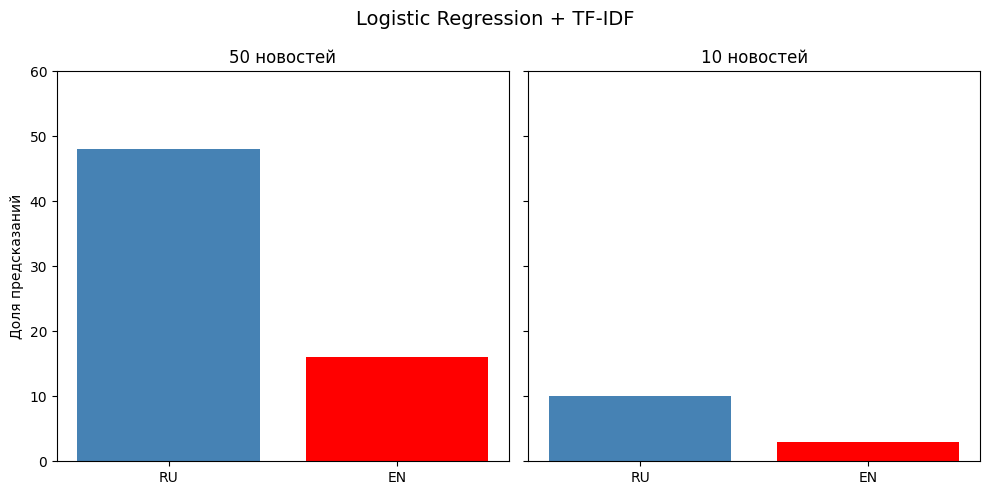

In [149]:
for model_name in model_pairs:
    key_rus_50 = f'Russian {model_name} 50'
    key_eng_50 = f'English {model_name} 50'
    key_rus_10 = f'Russian {model_name} 10'
    key_eng_10 = f'English {model_name} 10'

    percentage_50_rus = statistics_of_answers[key_rus_50]
    percentage_50_eng = statistics_of_answers[key_eng_50]
    percentage_10_rus = statistics_of_answers[key_rus_10]
    percentage_10_eng = statistics_of_answers[key_eng_10]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    # 50 новостей
    x1 = np.arange(2)
    axes[0].bar(x1, [percentage_50_rus, percentage_50_eng],
                color=['steelblue', 'red'])
    axes[0].set_xticks(x1)
    axes[0].set_xticklabels(['RU', 'EN'])
    axes[0].set_ylim(0, 60)
    axes[0].set_title('50 новостей')
    axes[0].set_ylabel('Доля предсказаний')

    # 10 новостей
    x2 = np.arange(2)
    axes[1].bar(x2, [percentage_10_rus, percentage_10_eng],
                color=['steelblue', 'red'])
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(['RU', 'EN'])
    axes[1].set_ylim(0, 60)
    axes[1].set_title('10 новостей')

    fig.suptitle(f'{model_name} + TF-IDF', fontsize=14)
    plt.tight_layout()
    plt.show()

    fig.savefig(f'assets/{model_name}_tfidf_comparison.png', dpi=300, bbox_inches='tight')

# Сравним теперь Word2Vec модели

## Предикт на русских данных

### Функции для обработки и предсказаний

In [118]:
def doc_vector(tokens, kv_model, max_len=150):
    """Среднее значение вектора из токенов."""
    if isinstance(tokens, str):
        tokens = tokens.split()[:max_len]
    else:
        tokens = tokens[:max_len]
    
    vecs = [kv_model[w] for w in tokens if w in kv_model]
    
    if not vecs:
        return np.zeros(kv_model.vector_size, dtype=np.float32)
    
    return np.vstack(vecs).mean(axis=0)

def cosine_similarity(u, v):
    """Косинусная близость между двумя векторами."""
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))

def jaccard_similarity(a_tokens, b_tokens):
    """Коэффициент Джаккара между двумя наборами токенов."""
    A, B = set(a_tokens), set(b_tokens)
    if not A and not B:
        return 0.0
    return len(A & B) / max(1, len(A | B))

def overlap_ratio(a_tokens, b_tokens):
    """Отношение пересечения к первому набору."""
    A, B = set(a_tokens), set(b_tokens)
    return 0.0 if not A else len(A & B) / len(A)

def build_feature_vector_w2v(headline_text, body_text, kv_model, max_len=150):
    """
    Построить полный вектор признаков для Word2Vec:
    [h_vec, b_vec, |h_vec - b_vec|, h_vec * b_vec, cosine, jaccard, overlap, l2_norm]
    """
    h_clean = preprocess_text(headline_text)
    b_clean = preprocess_text(body_text)
    
    h_tokens = h_clean.split()[:max_len]
    b_tokens = b_clean.split()[:max_len]
    
    h_vec = doc_vector(h_tokens, kv_model)
    b_vec = doc_vector(b_tokens, kv_model)
    
    cos_sim = cosine_similarity(h_vec, b_vec)
    jacc = jaccard_similarity(h_tokens, b_tokens)
    ovr = overlap_ratio(h_tokens, b_tokens)
    
    diff = np.abs(h_vec - b_vec)
    prod = h_vec * b_vec
    l2_dist = np.linalg.norm(h_vec - b_vec)
    
    features = np.hstack([h_vec, b_vec, diff, prod, [cos_sim, jacc, ovr, l2_dist]])
    
    return features

### Загрузка моделей и эмбеддинггов

In [119]:
models_to_load = {
    'Random Forest russian version': 'models/randomforest_model.pkl',
    'Logistic Regression russian version': 'models/logisticregression_model.pkl',
}

loaded_models = {}

for model_name, model_path in models_to_load.items():
    if os.path.exists(model_path):
        with open(model_path, 'rb') as f:
            loaded_models[model_name] = pickle.load(f)
        print(f"{model_name} загружена: {model_path}")
    else:
        print(f"{model_name} НЕ найдена: {model_path}")

kv_paths = {
    'kv rus': 'models/w2v_vectors.kv',
    'kv eng': 'models/w2v_vectors_eng.kv'
}

loaded_kvs = {}

for kv_name, kv_path in kv_paths.items():
    if os.path.exists(kv_path):
        loaded_kvs[kv_name] = KeyedVectors.load(kv_path)
        print(f"{kv_name} загружен: {kv_path}")
    else:
        print(f"{kv_name} НЕ найден: {kv_path}")

Random Forest russian version загружена: models/randomforest_model.pkl
Logistic Regression russian version загружена: models/logisticregression_model.pkl
kv rus загружен: models/w2v_vectors.kv
kv eng загружен: models/w2v_vectors_eng.kv


### Приводим датасет к необходимому виду

In [120]:
if 'label' not in comparsion_dataset_50.columns:
    comparsion_dataset_50['label'] = 1
    comparsion_dataset_50_eng['label'] = 1
    print("Добавил целевую переменную")

In [121]:
print(f"Датасет содержит {len(comparsion_dataset_50)} строк")

X_w2v_features = []
failed_rows = []
kv_model = loaded_kvs['kv rus']

for idx, row in comparsion_dataset_50.iterrows():
    try:
        headline = row['Headline'] if 'Headline' in row else row.get('headline', '')
        body = row['articleBody'] if 'articleBody' in row else row.get('body', '')
        
        features = build_feature_vector_w2v(headline, body, kv_model)
        X_w2v_features.append(features)
    except Exception as e:
        print(f"  ⚠ Ошибка на строке {idx}: {e}")
        failed_rows.append(idx)
        X_w2v_features.append(np.zeros(4 * kv_model.vector_size + 4, dtype=np.float32))

X_w2v = np.vstack(X_w2v_features)
y_true = comparsion_dataset_50['label'].values

print(f"✓ Признаки построены. Форма: {X_w2v.shape}")
if failed_rows:
    print(f"⚠ Ошибок на {len(failed_rows)} строках (заполнены нулями)")

Датасет содержит 50 строк
✓ Признаки построены. Форма: (50, 1204)


### Предикт

In [122]:
results = {}

for model_name, model in loaded_models.items():
    print(f"\n{model_name}:")
    
    try:
        y_pred = model.predict(X_w2v)
        y_proba = model.predict_proba(X_w2v)
        
        real_count = int(np.sum(y_pred == 1))
        
        results[model_name] = {
            # 'predictions': y_pred,
            # 'probabilities': y_proba,
            'real_count': real_count,
        }
        
        print(f"Классифицировано как РЕАЛЬНЫЕ: {real_count} ({real_count/50}%)")
    
    except Exception as e:
        print(f"   ✗ Ошибка при предсказании: {e}")


Random Forest russian version:
Классифицировано как РЕАЛЬНЫЕ: 48 (0.96%)

Logistic Regression russian version:
Классифицировано как РЕАЛЬНЫЕ: 46 (0.92%)


## Предикт на датасете на 50 строк на английском языке


### Загрузка эмбеддингов и моделей

In [123]:
kv = KeyedVectors.load('./models/w2v_vectors_eng.kv')

with open('./models/logisticregression_model_w2v_eng.pkl', 'rb') as f:
    logistic_model = pickle.load(f)

with open('./models/randomforest_model_w2v_eng.pkl', 'rb') as f:
    rf_model = pickle.load(f)

loaded_models = {
    'Logistic Regression english version': logistic_model,
    'Random Forest english version': rf_model,
}

### Функции для обработки и обучения модели

In [124]:
def doc_vector(tokens, kv_model):
    vecs = [kv_model[w] for w in tokens if w in kv_model]
    if not vecs:
        return np.zeros(kv_model.vector_size, dtype=np.float32)
    return np.vstack(vecs).mean(axis=0)

def build_features(df, kv_model, maxlen=150):
    H, B, COS = [], [], []

    for _, row in df.iterrows():
        htoks = str(row['Headline_en']).split()[:maxlen]
        btoks = str(row['articleBody_en']).split()[:maxlen]

        hvec = doc_vector(htoks, kv_model)
        bvec = doc_vector(btoks, kv_model)

        H.append(hvec)
        B.append(bvec)

        cos = float(
            np.dot(hvec, bvec) /
            (np.linalg.norm(hvec) * np.linalg.norm(bvec) + 1e-9)
        )
        COS.append(cos)

    H = np.vstack(H)
    B = np.vstack(B)
    COS = np.array(COS).reshape(-1, 1)

    X = np.hstack([H, B, COS])
    return X


### Загрузка данных для предикта

In [125]:
X_w2v = build_features(comparsion_dataset_50_eng, kv)
print('X_w2v shape:', X_w2v.shape)

X_w2v shape: (50, 601)


### Предикт

In [126]:
results_eng = {}

for model_name, model in loaded_models.items():
    print(f"\n{model_name}:")
    try:
        y_pred = model.predict(X_w2v)
        y_proba = model.predict_proba(X_w2v)

        real_count = int(np.sum(y_pred == 1))

        results_eng[model_name] = {
            # 'predictions': y_pred,
            # 'probabilities': y_proba,
            'real_count': real_count,
        }

        print(f"Классифицировано как РЕАЛЬНЫЕ: {real_count} ({real_count/len(y_pred):.2%})")

    except Exception as e:
        print(f"   ✗ Ошибка при предсказании: {e}")


Logistic Regression english version:
Классифицировано как РЕАЛЬНЫЕ: 25 (50.00%)

Random Forest english version:
Классифицировано как РЕАЛЬНЫЕ: 19 (38.00%)


## Результаты и сравнение

In [139]:
lr_results, rf_results = {}, {}

lr_results["RU"] = results["Logistic Regression russian version"]
lr_results["EN"] = results_eng["Logistic Regression english version"]

rf_results["RU"] = results["Random Forest russian version"]
rf_results["EN"] = results_eng["Random Forest english version"]

In [132]:
lr_results

{'Logistic Regression russian version': {'real_count': 46},
 'Logistic Regression english version': {'real_count': 25}}

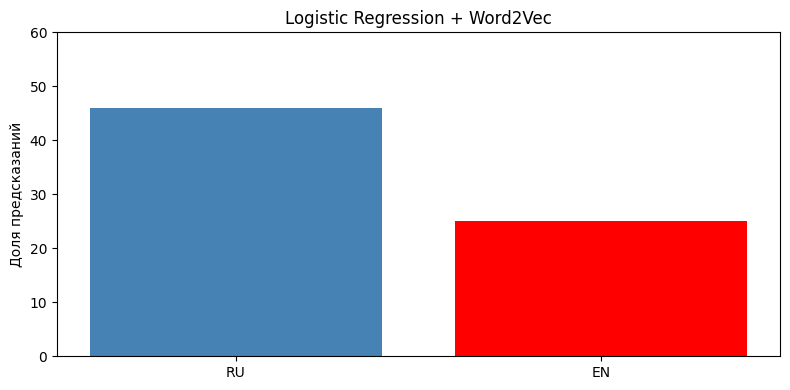

In [152]:
names = list(lr_results.keys())
values = [v["real_count"] for v in lr_results.values()]

plt.figure(figsize=(8, 4))
plt.bar(names, values, color=['steelblue', 'red'])
plt.ylabel("Доля предсказаний")
plt.title("Logistic Regression + Word2Vec")
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

fig.savefig(f'assets/logisticregression_w2v_comparison.png', dpi=300, bbox_inches='tight')

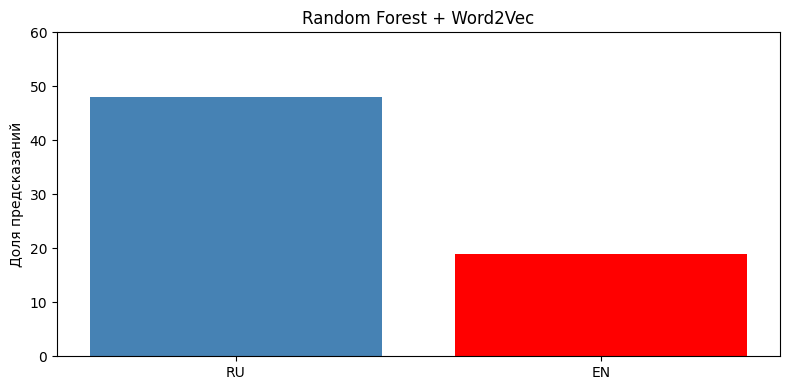

In [153]:
names = list(lr_results.keys())
values = [v["real_count"] for v in rf_results.values()]

plt.figure(figsize=(8, 4))
plt.bar(names, values, color=['steelblue', 'red'])
plt.ylabel("Доля предсказаний")
plt.title("Random Forest + Word2Vec")
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

fig.savefig(f'assets/randomforest_w2v_comparison.png', dpi=300, bbox_inches='tight')